<a href="https://colab.research.google.com/github/YM1587/ALX-PYTHON/blob/main/MNIST_ANALYSIS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 — IMPORT & LOAD DATA

MNIST (28×28 grayscale)

In [1]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape for ML models
X_train_ml = X_train.reshape(len(X_train), -1)
X_test_ml = X_test.reshape(len(X_test), -1)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


STEP 2 — BASIC EDA

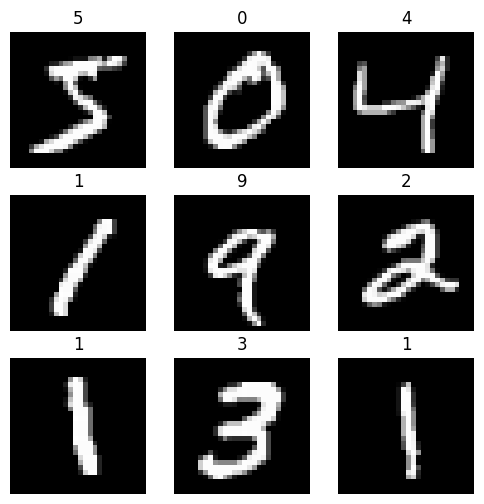

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(X, y, classes, n=9):
    plt.figure(figsize=(6,6))
    for i in range(n):
        plt.subplot(3,3,i+1)
        plt.imshow(X[i], cmap='gray' if X.ndim==3 else None)
        plt.title(classes[y[i]])
        plt.axis('off')
    plt.show()

mnist_classes = [str(i) for i in range(10)]
show_samples(X_train, y_train, mnist_classes)


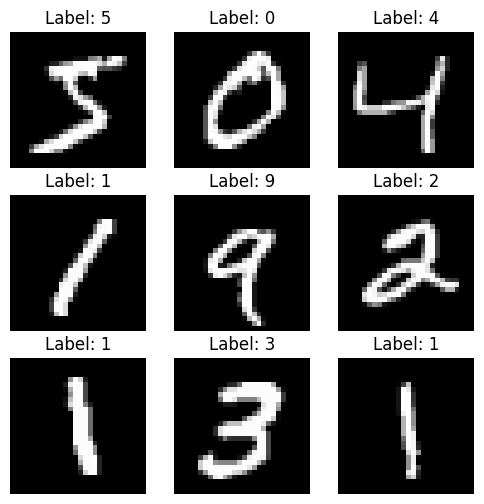

In [3]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


STEP 3 — SCALING FOR ML MODELS

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_ml = scaler.fit_transform(X_train_ml)
X_test_ml = scaler.transform(X_test_ml)


In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
plt.show()


STEP 4 — KNN


              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.99      0.97      1135
           2       0.96      0.93      0.94      1032
           3       0.92      0.95      0.94      1010
           4       0.94      0.94      0.94       982
           5       0.93      0.92      0.93       892
           6       0.96      0.97      0.97       958
           7       0.94      0.92      0.93      1028
           8       0.96      0.90      0.93       974
           9       0.92      0.92      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



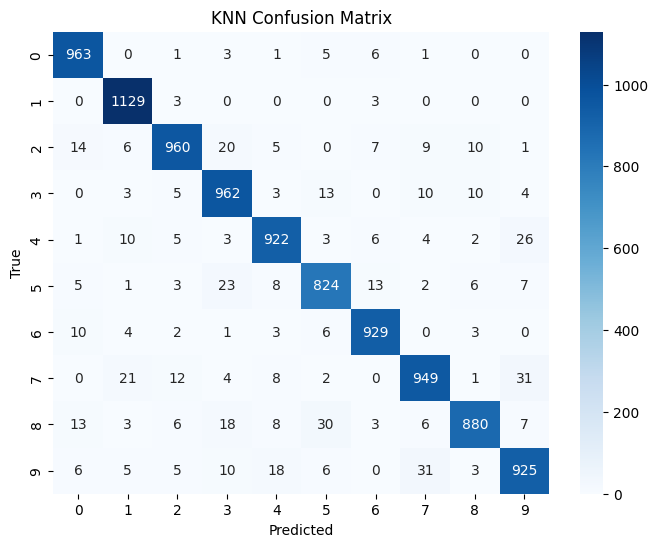

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_ml, y_train)
pred_knn = knn.predict(X_test_ml)

print(classification_report(y_test, pred_knn))
plot_cm(y_test, pred_knn, "KNN Confusion Matrix")


STEP 5 — SVM (all kernels)


SVM Kernel: linear
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       980
           1       0.96      0.99      0.97      1135
           2       0.90      0.93      0.91      1032
           3       0.90      0.93      0.91      1010
           4       0.92      0.95      0.93       982
           5       0.91      0.88      0.90       892
           6       0.96      0.94      0.95       958
           7       0.95      0.92      0.93      1028
           8       0.91      0.88      0.90       974
           9       0.94      0.89      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000


SVM Kernel: poly
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.94      0

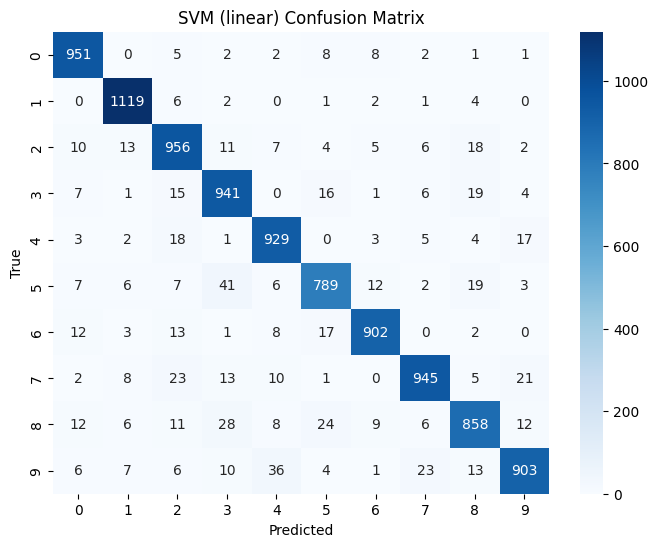

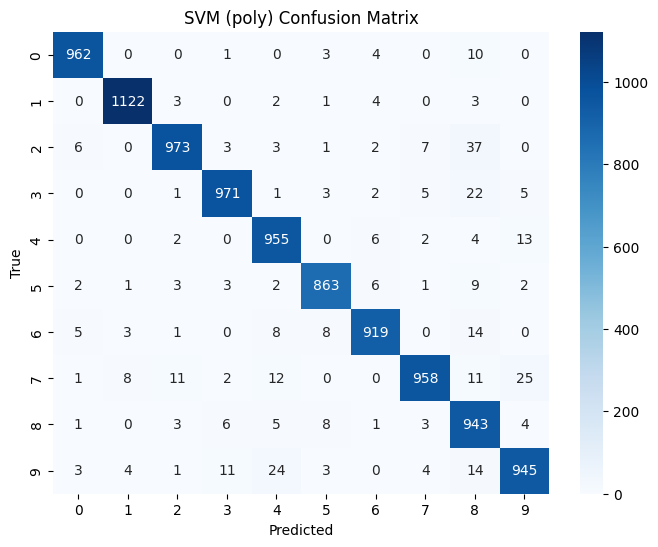

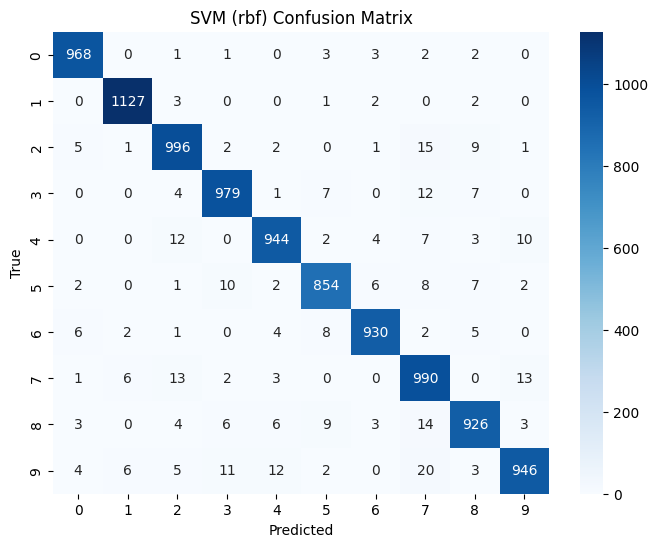

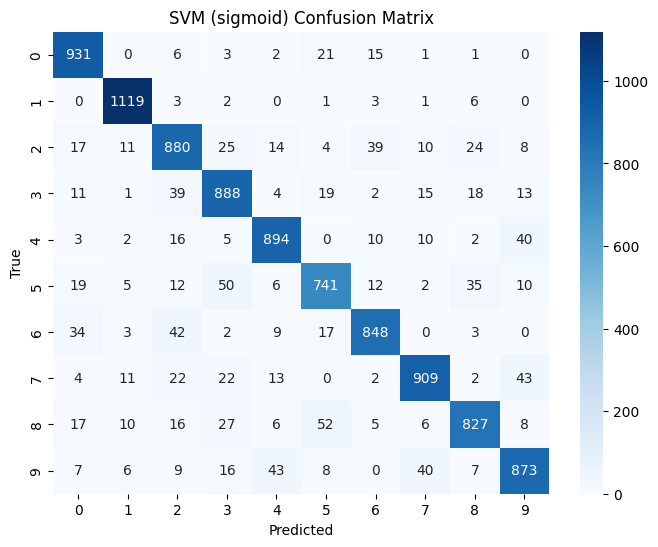

In [8]:
from sklearn.svm import SVC

kernels = ['linear','poly','rbf','sigmoid']

for k in kernels:
    svm = SVC(kernel=k)
    svm.fit(X_train_ml, y_train)
    pred = svm.predict(X_test_ml)
    print(f"\nSVM Kernel: {k}")
    print(classification_report(y_test, pred))
    plot_cm(y_test, pred, f"SVM ({k}) Confusion Matrix")



DECISION TREES — ID3 & CART
ID3 (entropy)
CART (gini)

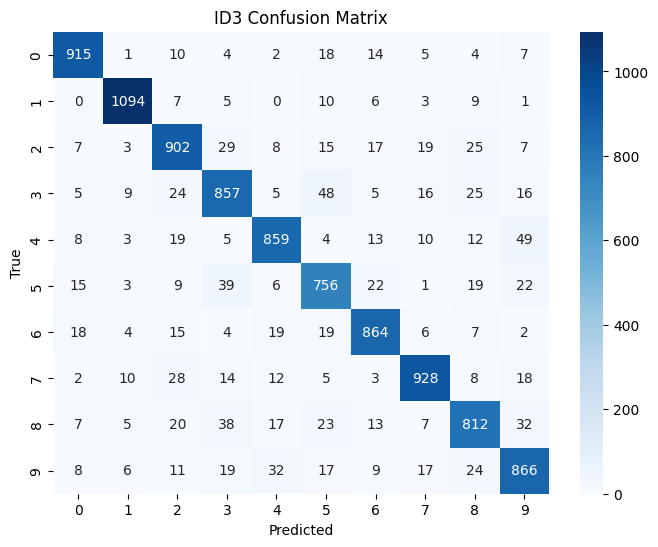

In [9]:
from sklearn.tree import DecisionTreeClassifier

id3 = DecisionTreeClassifier(criterion='entropy')
id3.fit(X_train_ml, y_train)
pred_id3 = id3.predict(X_test_ml)

plot_cm(y_test, pred_id3, "ID3 Confusion Matrix")


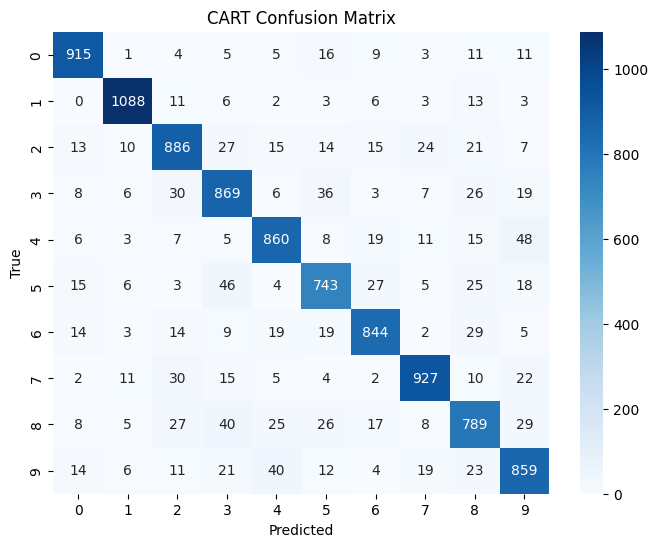

In [10]:
cart = DecisionTreeClassifier(criterion='gini')
cart.fit(X_train_ml, y_train)
pred_cart = cart.predict(X_test_ml)

plot_cm(y_test, pred_cart, "CART Confusion Matrix")


RANDOM FOREST

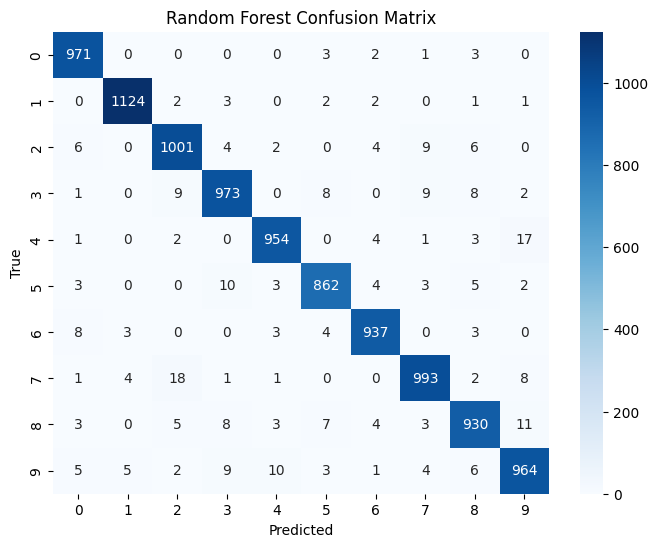

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train_ml, y_train)
pred_rf = rf.predict(X_test_ml)

plot_cm(y_test, pred_rf, "Random Forest Confusion Matrix")


BOOSTING

AdaBoost

Gradient Boosting


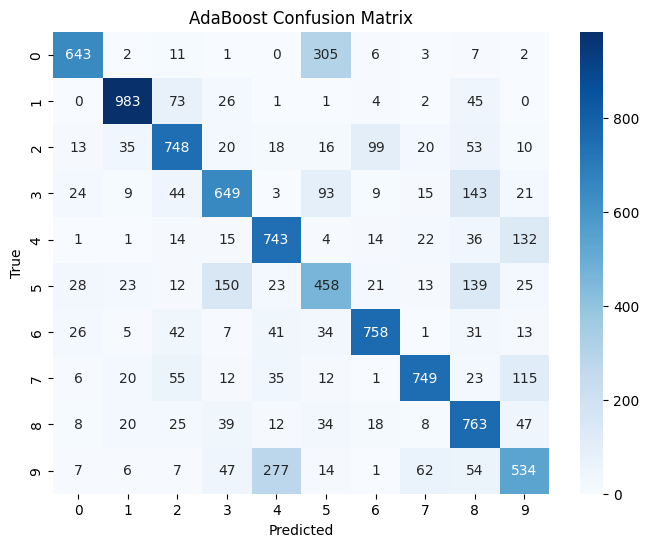

In [12]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_train_ml, y_train)
pred_ada = ada.predict(X_test_ml)

plot_cm(y_test, pred_ada, "AdaBoost Confusion Matrix")


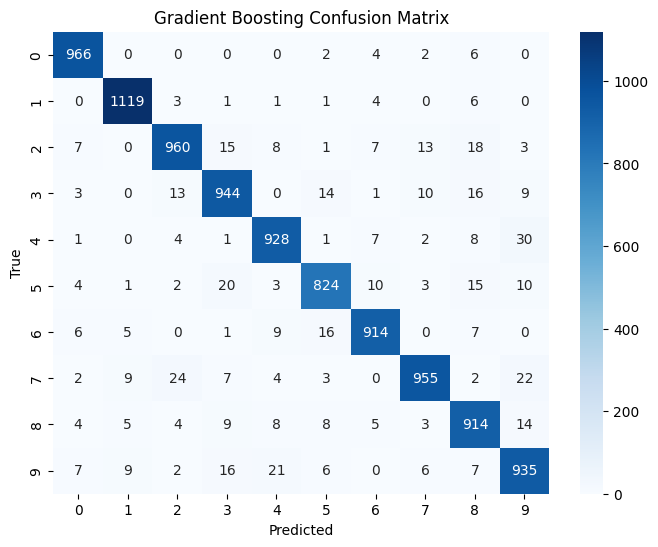

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_ml, y_train)
pred_gb = gb.predict(X_test_ml)

plot_cm(y_test, pred_gb, "Gradient Boosting Confusion Matrix")


ANN (MLP)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8953 - loss: 3.2901
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9336 - loss: 0.4135
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9476 - loss: 0.2451
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9545 - loss: 0.2067
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9569 - loss: 0.1909
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


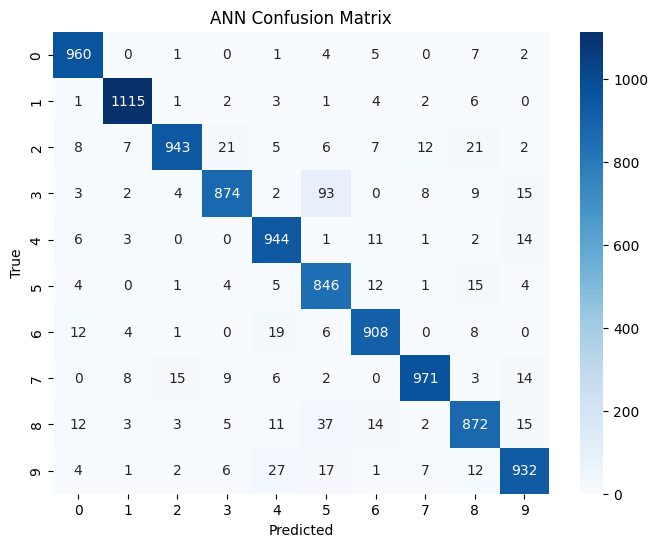

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

ann.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5, batch_size=64)

pred_ann = ann.predict(X_test).argmax(axis=1)
plot_cm(y_test, pred_ann, "ANN Confusion Matrix")


RNN (LSTM)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.8419 - loss: 0.4970
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9524 - loss: 0.1577
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9664 - loss: 0.1133
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


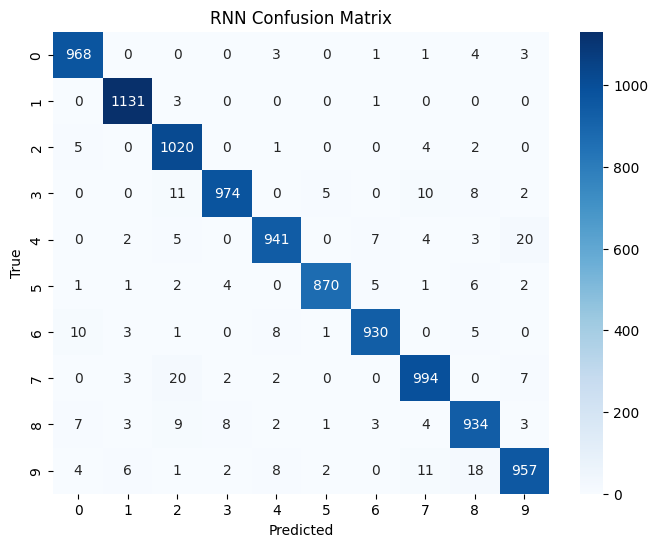

In [15]:
from tensorflow.keras.layers import LSTM

X_train_r = X_train / 255.0
X_test_r = X_test / 255.0

rnn = Sequential([
    LSTM(64, input_shape=(28,28)),
    Dense(10, activation='softmax')
])

rnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

rnn.fit(X_train_r, y_train, epochs=3, batch_size=64)

pred_rnn = rnn.predict(X_test_r).argmax(axis=1)
plot_cm(y_test, pred_rnn, "RNN Confusion Matrix")


CNN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 49ms/step - accuracy: 0.9523 - loss: 0.1592
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9856 - loss: 0.0467
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9901 - loss: 0.0324
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


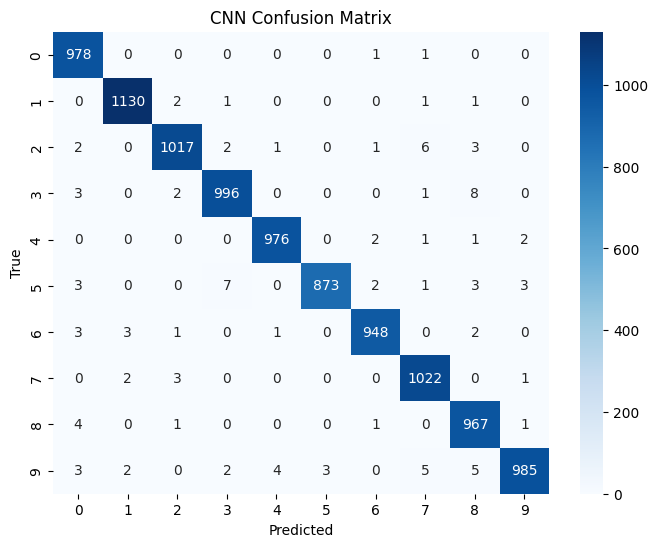

In [16]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

X_train_c = X_train.reshape(-1,28,28,1) / 255.0
X_test_c = X_test.reshape(-1,28,28,1) / 255.0

cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.fit(X_train_c, y_train, epochs=3, batch_size=64)

pred_cnn = cnn.predict(X_test_c).argmax(axis=1)
plot_cm(y_test, pred_cnn, "CNN Confusion Matrix")


TRANSFORMER (VISION TRANSFORMER)

In [17]:
!pip install keras-cv --quiet

import keras_cv
from tensorflow import keras

vit = keras_cv.models.VisionTransformerClassifier(
    num_classes=10,
    image_size=28,
    patch_size=7,
    transformer_layers=4,
    num_heads=4,
    embed_dim=64
)

vit.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

vit.fit(X_train_c, y_train, epochs=3, batch_size=64)

pred_vit = vit.predict(X_test_c).argmax(axis=1)
plot_cm(y_test, pred_vit, "Transformer Confusion Matrix")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 31.7 MB/s eta 0:00:00


AttributeError: module 'keras_cv.api.models' has no attribute 'VisionTransformerClassifier'